In [340]:
%reload_ext autoreload
%autoreload 2

In [345]:
import jax 
import jax.numpy as jnp

import haiku as hk

from probjax.nn.loss_fn import score_matching_loss, sliced_score_matching
import matplotlib.pyplot as plt 

In [358]:
d = 1

def model(t, x):
    x = x
    return hk.Sequential([
        hk.Linear(128), jax.nn.gelu,
        hk.Linear(128), jax.nn.gelu,
        hk.Linear(d)
    ])(x)
    
init_fn, model_fn = hk.without_apply_rng(hk.transform(model))

key = jax.random.PRNGKey(0)
x = jax.random.normal(key, (10,d))
times = jnp.array([0.])


mu1 = -2.0 * jnp.ones((d,))
mu2 = 2.0* jnp.ones((d,))
sigma = 0.5* jnp.ones((d,))

@jax.grad
def target_score(x):
    logpdf1 = jax.scipy.stats.norm.logpdf(x, mu1, sigma) + jnp.log(0.5)
    logpdf2 = jax.scipy.stats.norm.logpdf(x, mu2, sigma) + jnp.log(0.5)
    logpdf = jax.scipy.special.logsumexp(jnp.stack([logpdf1, logpdf2], axis=0), axis=0)
    return logpdf.sum()

def sample(key, n):
    key1, key2 = jax.random.split(key)
    n1, n2 = n//2, n-n//2
    x1 = jax.random.normal(key1, (n1,d))* sigma + mu1
    x2 = jax.random.normal(key2, (n2,d))* sigma + mu2
    return jnp.concatenate([x1, x2], axis=0)
    

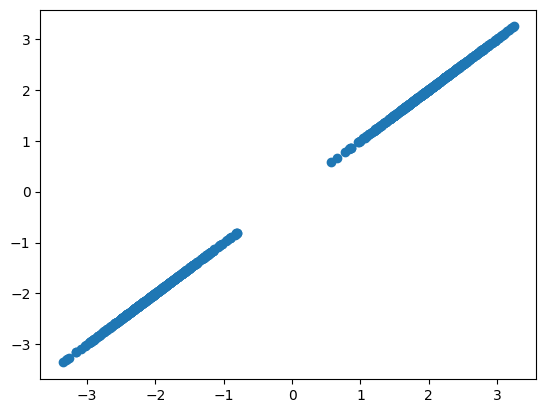

In [359]:
samples = sample(key, 1000)
plt.scatter(samples[:,0], samples[:,1])

In [428]:
params = init_fn(key, jnp.ones(10,),x)

In [429]:
xs = jax.random.normal(key, (1000,1))
times = jnp.ones((1000,))

In [448]:
import optax 
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

def loss_fn(params, times, xs):
    return score_matching_loss(params, times, xs, model_fn, tikhonov=0.0)


@jax.jit
def update(params,rng,opt_state, times, xs):
    loss, grads = jax.value_and_grad(loss_fn)(params, times, xs)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, opt_state

In [441]:
import optax 
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

def loss_fn(params, rng,times, xs):
    return sliced_score_matching(params, rng,times, xs, model_fn, num_slices=5, sliced_dist="normal", tikhonov=0.)


@jax.jit
def update(params,rng,opt_state, times, xs):
    loss, grads = jax.value_and_grad(loss_fn)(params,rng, times, xs)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, opt_state

In [450]:
for i in range(10_000):
    key, subkey, subsubkey = jax.random.split(key,3)
    xs = jax.jit(sample, static_argnums=1)(subkey, 1000)
    loss, params, optimizer = update(params, subsubkey,opt_state,times, xs)
    if i % 1000 == 0:
        print(loss)

-2.1841261
-1.870122
-1.9971175
-1.9545493
-2.0614073
-1.9560282
-2.0712476
-2.0478768
-1.9104071
-1.9926205


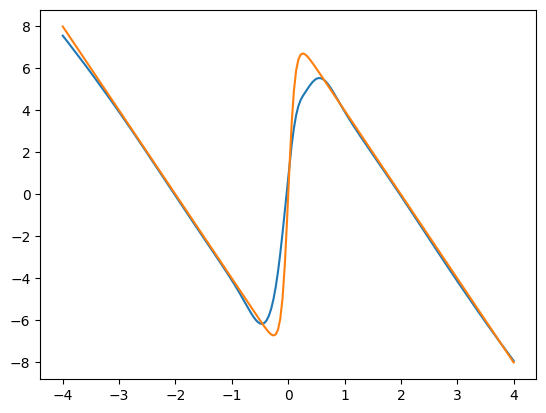

In [451]:

import matplotlib.pyplot as plt

if d == 1:
    x_test = jnp.linspace(-4,4,200)[:,None]
    times_test = jnp.ones((200,))
    y = model_fn(params, times_test, x_test)
    y_true = target_score(x_test)
    plt.plot(x_test, y)
    plt.plot(x_test, y_true)
else:
    samples_test = sample(key, 1000)
    y = model_fn(params, times, samples_test)
    y_true = target_score(samples_test)
    loss = jnp.mean((y - y_true)**2)
    print(loss)
